In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Настройки для красивых графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Загружаем все файлы
customers = pd.read_csv('customer_profiles.csv')
accounts = pd.read_csv('bank_accounts.csv')
transactions = pd.read_csv('account_transactions.csv')
transaction_codes = pd.read_csv('transaction_codes.csv')

In [8]:
print("=== КЛИЕНТЫ ===")
print(customers.head())
print("\nКолонки:", customers.columns.tolist())

print("\n=== СЧЕТА ===")
print(accounts.head())
print("\nКолонки:", accounts.columns.tolist())

print("\n=== ТРАНЗАКЦИИ ===")
print(transactions.head())
print("\nКолонки:", transactions.columns.tolist())

print("\n=== ТИПЫ ТРАНЗАКЦИЙ ===")
print(transaction_codes.head())

=== КЛИЕНТЫ ===
                            customer_id  national_id  birth_date  \
0  dc3dd10b-91ed-4453-89bb-9f624c441030  UA886206902  1976-04-04   
1  d8946376-be1f-48cc-a278-f8b3b967cd77  IB516472288  1971-08-19   
2  83fae1e1-7a78-42d4-81fd-803ebdeedb2d  CS768525777  1997-10-11   
3  24405b2f-c105-4f3f-9aaf-8bc07f4cae9f  RX998412214  1954-11-12   
4  3869d8bc-f40c-4f5e-a283-6137c3c35e49  DT348481917  1998-02-13   

           city     state  
0       Houston     Texas  
1  Grand Rapids  Michigan  
2    Naperville  Illinois  
3        Austin     Texas  
4     Las Vegas    Nevada  

Колонки: ['customer_id', 'national_id', 'birth_date', 'city', 'state']

=== СЧЕТА ===
                             account_id                           customer_id  \
0  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea  dc3dd10b-91ed-4453-89bb-9f624c441030   
1  bb9837da-5ee5-4d30-9c22-b2d6e2fffafa  dc3dd10b-91ed-4453-89bb-9f624c441030   
2  2ab94e36-bff3-45e8-8db7-966075a889d6  d8946376-be1f-48cc-a278-f8b3b967cd77

In [9]:
# Сначала связываем счета с клиентами
accounts_with_customers = pd.merge(accounts, customers, on='customer_id', how='left')

# Потом транзакции со счетами (и клиентами заодно)
merged = pd.merge(transactions, accounts_with_customers, on='account_id', how='left')

# Добавляем названия типов транзакций (если нужно)
# merged = pd.merge(merged, transaction_codes, on='transaction_code', how='left')

print(f"✅ Объединено записей: {len(merged)}")
print("\nПервые 5 строк объединённых данных:")
print(merged.head())

✅ Объединено записей: 2377169

Первые 5 строк объединённых данных:
                         transaction_id                            account_id  \
0  f5526a0f-4ec2-4aa4-a01e-33034d40ec33  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea   
1  b1c5757f-587d-418b-9238-35c4e338b731  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea   
2  f248fe0e-b646-4df6-a9d8-e8ebcd386c92  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea   
3  44314720-e02d-4c39-8aaf-b0d81380225d  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea   
4  9dcabefa-fe70-4d3f-b29e-22c442cba3dd  eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea   

  linked_transaction_id         created_time transaction_type  \
0                   NaN  2023-04-21 12:55:00           Credit   
1                   NaN  2023-04-22 11:18:00           Credit   
2                   NaN  2023-04-22 12:16:00           Credit   
3                   NaN  2023-04-22 14:15:00            Debit   
4                   NaN  2023-04-22 16:24:00            Debit   

  transaction_code   amount          channel  \
0      

In [10]:
print("=== Структура объединённых данных ===")
print(merged.info())
print("\n=== Статистика по суммам транзакций ===")
print(merged['amount'].describe())

=== Структура объединённых данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2377169 entries, 0 to 2377168
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   transaction_id         object 
 1   account_id             object 
 2   linked_transaction_id  object 
 3   created_time           object 
 4   transaction_type       object 
 5   transaction_code       object 
 6   amount                 float64
 7   channel                object 
 8   customer_id            object 
 9   account_type           object 
 10  creation_date          object 
 11  account_status         object 
 12  balance                float64
 13  loan_amount            float64
 14  term_months            float64
 15  interest_rate          float64
 16  national_id            object 
 17  birth_date             object 
 18  city                   object 
 19  state                  object 
dtypes: float64(5), object(15)
memory usage: 362.7+ MB
No

In [12]:
# Метрики по каждому клиенту (группируем по customer_id)
client_metrics = merged.groupby('customer_id').agg({
    'transaction_id': 'count',           # количество покупок
    'amount': ['sum', 'mean'],           # суммарно и средний чек
    'birth_date': 'first',               # дата рождения (если есть)
    'city': 'first',                     # город
    'state': 'first'                     # штат/регион
}).reset_index()

# Переименовываем колонки для удобства
client_metrics.columns = ['customer_id', 'purchase_count', 'total_spent', 'avg_check', 
                          'birth_date', 'city', 'state']

# Вычисляем возраст (если есть дата рождения)
if 'birth_date' in client_metrics.columns and not client_metrics['birth_date'].isnull().all():
    client_metrics['birth_date'] = pd.to_datetime(client_metrics['birth_date'])
    client_metrics['age'] = (pd.Timestamp.now() - client_metrics['birth_date']).dt.days // 365
else:
    client_metrics['age'] = np.nan

print("✅ Метрики по клиентам посчитаны!")
print(f"Всего клиентов с транзакциями: {len(client_metrics)}")

✅ Метрики по клиентам посчитаны!
Всего клиентов с транзакциями: 1000


In [13]:
# Считаем ARPU
arpu = client_metrics['total_spent'].mean()
avg_check = client_metrics['avg_check'].mean()
avg_purchases = client_metrics['purchase_count'].mean()
max_spent = client_metrics['total_spent'].max()

print("="*50)
print("📊 КЛЮЧЕВЫЕ МЕТРИКИ")
print("="*50)
print(f"💰 ARPU (средний доход на клиента): ${arpu:.2f}")
print(f"🧾 Средний чек: ${avg_check:.2f}")
print(f"🛒 Среднее количество покупок: {avg_purchases:.1f}")
print(f"🏆 Максимальная выручка с клиента: ${max_spent:.2f}")

📊 КЛЮЧЕВЫЕ МЕТРИКИ
💰 ARPU (средний доход на клиента): $2165793.34
🧾 Средний чек: $1135.60
🛒 Среднее количество покупок: 2377.2
🏆 Максимальная выручка с клиента: $14034623.78


=== Распределение по сегментам ===
segment
🔴 Premium    1000
Name: count, dtype: int64


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


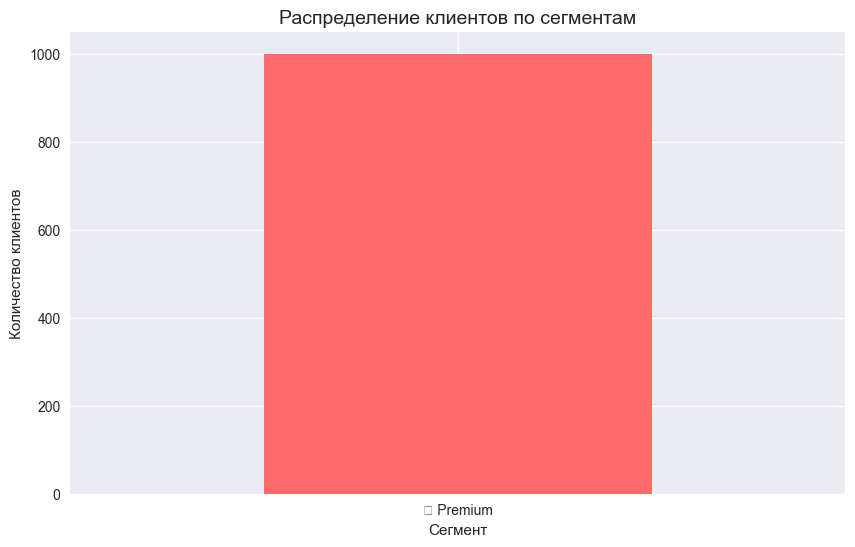

In [14]:
# Создаём сегменты по сумме покупок
def assign_segment(spent):
    if spent > 5000:
        return '🔴 Premium'
    elif spent > 2000:
        return '🟡 Gold'
    elif spent > 500:
        return '🟢 Silver'
    else:
        return '🔵 Bronze'

client_metrics['segment'] = client_metrics['total_spent'].apply(assign_segment)

print("=== Распределение по сегментам ===")
print(client_metrics['segment'].value_counts())

# Визуализация
plt.figure(figsize=(10,6))
client_metrics['segment'].value_counts().plot(kind='bar', color=['#FF6B6B', '#FECB6E', '#4ECDC4', '#45B7D1'])
plt.title('Распределение клиентов по сегментам', fontsize=14)
plt.xlabel('Сегмент')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.show()

In [15]:
# LTV (прогнозируем на 3 года)
client_metrics['ltv'] = client_metrics['avg_check'] * 12 * 3

# CAC (для примера: 20% от первого чека)
client_metrics['cac'] = client_metrics['avg_check'] * 0.2

# Соотношение LTV/CAC
client_metrics['ltv_cac_ratio'] = client_metrics['ltv'] / client_metrics['cac']

print("=== Юнит-экономика по сегментам ===")
segments_summary = client_metrics.groupby('segment').agg({
    'ltv': 'mean',
    'cac': 'mean',
    'ltv_cac_ratio': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'count'}).round(2)
print(segments_summary)

# Вывод по каждому клиенту (топ-5)
print("\n=== Топ-5 клиентов по LTV/CAC ===")
print(client_metrics[['customer_id', 'segment', 'ltv', 'cac', 'ltv_cac_ratio']]
      .sort_values('ltv_cac_ratio', ascending=False).head())

=== Юнит-экономика по сегментам ===
                ltv     cac  ltv_cac_ratio  count
segment                                          
🔴 Premium  40881.51  227.12          180.0   1000

=== Топ-5 клиентов по LTV/CAC ===
                              customer_id    segment            ltv  \
179  2b88a533-db73-42a4-bfa5-696d7d42c45f  🔴 Premium   53605.227298   
873  e0530cd5-6eed-44c8-9e17-2f8b90fa2deb  🔴 Premium   58253.998175   
61   0e445b51-c4ef-4469-b5bc-0b5aac6a46b0  🔴 Premium   25885.269333   
7    0184898f-78e0-44b8-b257-a7c6d792b689  🔴 Premium  292910.315086   
8    01901be1-bbed-4b83-9298-1e2946799654  🔴 Premium   40871.571546   

             cac  ltv_cac_ratio  
179   297.806818          180.0  
873   323.633323          180.0  
61    143.807052          180.0  
7    1627.279528          180.0  
8     227.064286          180.0  


C:\Users\HP\AppData\Local\Temp\ipykernel_18552\2544046525.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


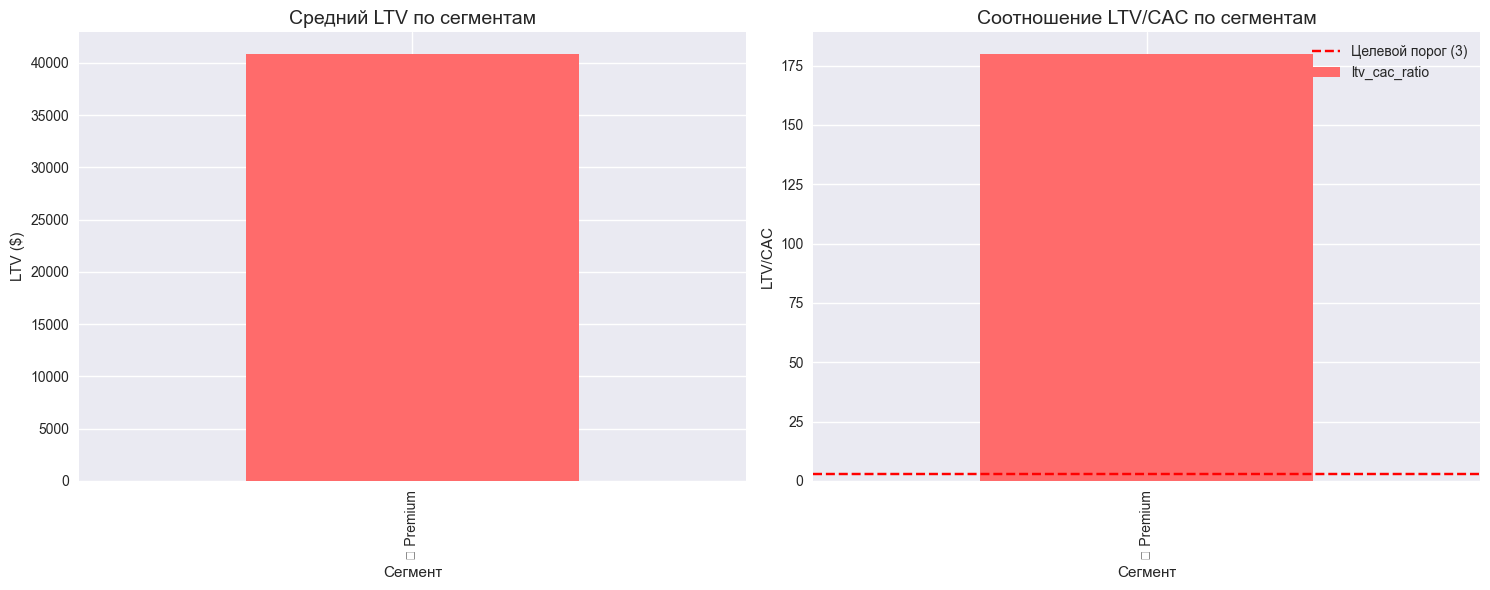

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: LTV по сегментам
segments = client_metrics.groupby('segment')
avg_ltv = segments['ltv'].mean()
avg_ltv.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#FECB6E', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Средний LTV по сегментам', fontsize=14)
axes[0].set_ylabel('LTV ($)')
axes[0].set_xlabel('Сегмент')

# График 2: Соотношение LTV/CAC
avg_ratio = segments['ltv_cac_ratio'].mean()
avg_ratio.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#FECB6E', '#4ECDC4', '#45B7D1'])
axes[1].axhline(y=3, color='red', linestyle='--', label='Целевой порог (3)')
axes[1].set_title('Соотношение LTV/CAC по сегментам', fontsize=14)
axes[1].set_ylabel('LTV/CAC')
axes[1].set_xlabel('Сегмент')
axes[1].legend()

plt.tight_layout()
plt.show()

=== Retention по сегментам ===
           total  returned  retention_rate
segment                                   
🔴 Premium   1000      1000           100.0


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


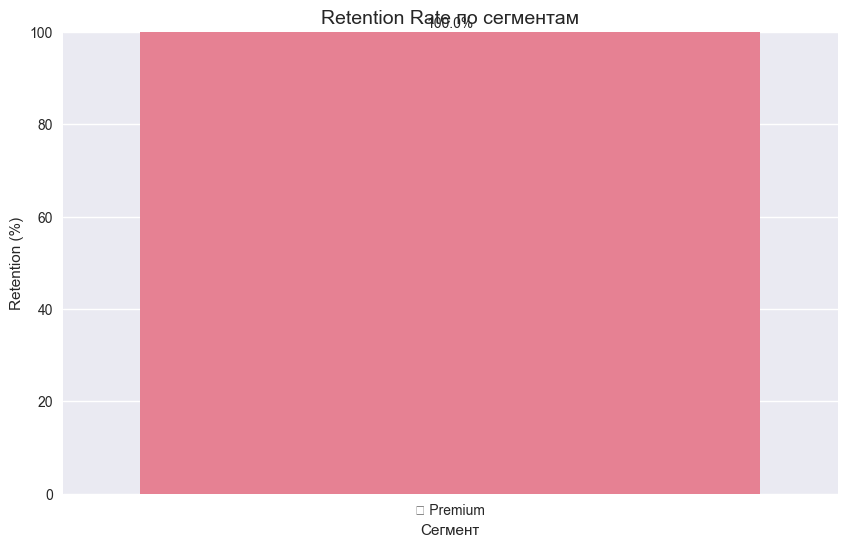

In [17]:
# Считаем Retention (доля клиентов, совершивших >1 покупку)
retention_data = client_metrics.groupby('segment').agg({
    'customer_id': 'count',                      # всего клиентов
    'purchase_count': lambda x: (x > 1).sum()   # купили >1 раза
}).rename(columns={'customer_id': 'total', 'purchase_count': 'returned'})

retention_data['retention_rate'] = (retention_data['returned'] / retention_data['total']) * 100

print("=== Retention по сегментам ===")
print(retention_data.round(2))

# Визуализация
plt.figure(figsize=(10,6))
sns.barplot(x=retention_data.index, y='retention_rate', data=retention_data)
plt.title('Retention Rate по сегментам', fontsize=14)
plt.ylabel('Retention (%)')
plt.xlabel('Сегмент')
plt.ylim(0, 100)
for i, v in enumerate(retention_data['retention_rate']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.show()

In [18]:
# Создаём случайные группы для A/B-теста
np.random.seed(42)
client_metrics['test_group'] = np.random.choice(['A', 'B'], size=len(client_metrics))

# Считаем метрики по группам
group_metrics = client_metrics.groupby('test_group').agg({
    'total_spent': 'mean',
    'purchase_count': 'mean',
    'ltv': 'mean'
}).round(2)

print("=== Метрики по группам для A/B-теста ===")
print(group_metrics)

# Проверяем разницу через t-test
group_a = client_metrics[client_metrics['test_group'] == 'A']['total_spent']
group_b = client_metrics[client_metrics['test_group'] == 'B']['total_spent']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f"\n📊 Результаты A/B-теста:")
print(f"   t-статистика: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")

if p_value < 0.05:
    print("   ✅ Разница статистически значима (p < 0.05)")
else:
    print("   ❌ Разница НЕ статистически значима (p >= 0.05)")

=== Метрики по группам для A/B-теста ===
            total_spent  purchase_count       ltv
test_group                                       
A            2162277.72         2358.39  40705.80
B            2169171.10         2395.22  41050.34

📊 Результаты A/B-теста:
   t-статистика: -0.059
   p-value: 0.9533
   ❌ Разница НЕ статистически значима (p >= 0.05)


In [19]:
# Определяем лучший и худший сегмент
best_segment = client_metrics.groupby('segment')['ltv_cac_ratio'].mean().idxmax()
worst_segment = client_metrics.groupby('segment')['ltv_cac_ratio'].mean().idxmin()
avg_retention = retention_data['retention_rate'].mean()

print("="*60)
print("📊 ИТОГОВЫЙ АНАЛИЗ ДАННЫХ БАНКА")
print("="*60)
print(f"\n💰 Общий ARPU: ${arpu:.2f}")
print(f"🔄 Средний Retention: {avg_retention:.1f}%")
print(f"🏆 Самый прибыльный сегмент: {best_segment}")
print(f"⚠️  Самый проблемный сегмент: {worst_segment}")

print(f"\n💡 Рекомендации:")
if 'Premium' in best_segment:
    print("   - Инвестировать больше в удержание Premium-клиентов")
if 'Bronze' in worst_segment or 'Silver' in worst_segment:
    print("   - Пересмотреть онбординг для Bronze/Silver-сегмента")
    print("   - Запустить A/B-тест для увеличения первого чека")

print("\n📈 Что делать дальше:")
print("   1. Построить дашборд в Tableau Public для мониторинга метрик")
print("   2. Провести A/B-тест для проблемного сегмента")
print("   3. Оптимизировать CAC через таргетированные кампании")

# Сохраняем результаты для дашборда
client_metrics.to_csv('analysis_results.csv', index=False)
print("\n✅ Результаты сохранены в 'analysis_results.csv' для дашборда")

📊 ИТОГОВЫЙ АНАЛИЗ ДАННЫХ БАНКА

💰 Общий ARPU: $2165793.34
🔄 Средний Retention: 100.0%
🏆 Самый прибыльный сегмент: 🔴 Premium
⚠️  Самый проблемный сегмент: 🔴 Premium

💡 Рекомендации:
   - Инвестировать больше в удержание Premium-клиентов

📈 Что делать дальше:
   1. Построить дашборд в Tableau Public для мониторинга метрик
   2. Провести A/B-тест для проблемного сегмента
   3. Оптимизировать CAC через таргетированные кампании

✅ Результаты сохранены в 'analysis_results.csv' для дашборда
